In [1]:
import sys
print(sys.executable)

c:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\.venv\Scripts\python.exe


In [2]:
%pip install tensorflow

import tensorflow as tf
print(tf.__version__)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


2.21.0


In [4]:
%pip install pandas



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
print(pd.__version__)

3.0.3


In [8]:
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_news.csv"

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data path:", CLEANED_DATA_PATH)

Project root: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector
Cleaned data path: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\data\processed\cleaned_news.csv


In [10]:
data = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", data.shape)
print(data.columns)

display(data.head())

Dataset shape: (39098, 3)
Index(['content', 'clean_text', 'label'], dtype='str')


,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Duri...,pope francis called donald trump christmas spe...,0


In [11]:
data["clean_text"] = data["clean_text"].fillna("").astype(str)

X = data["clean_text"]
y = data["label"].astype(int)

print("Total records:", len(X))
print("Class distribution:")
print(y.value_counts())

Total records: 39098
Class distribution:
label
1    21196
0    17902
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 31278
Testing size: 7820


In [13]:
MAX_WORDS = 20000
MAX_LEN = 300
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (31278, 300)
X_test_pad shape: (7820, 300)


In [14]:
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

c:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1111s 3s/step - accuracy: 0.5385 - loss: 0.6996 - val_accuracy: 0.5241 - val_loss: 0.6789
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 837s 2s/step - accuracy: 0.7343 - loss: 0.5167 - val_accuracy: 0.8339 - val_loss: 0.4076
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 864s 2s/step - accuracy: 0.8506 - loss: 0.3943 - val_accuracy: 0.8680 - val_loss: 0.3585
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 828s 2s/step - accuracy: 0.8627 - loss: 0.3750 - val_accuracy: 0.7418 - val_loss: 0.6250
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 608s 2s/step - accuracy: 0.5513 - loss: 0.6846 - val_accuracy: 0.5408 - val_loss: 0.6772


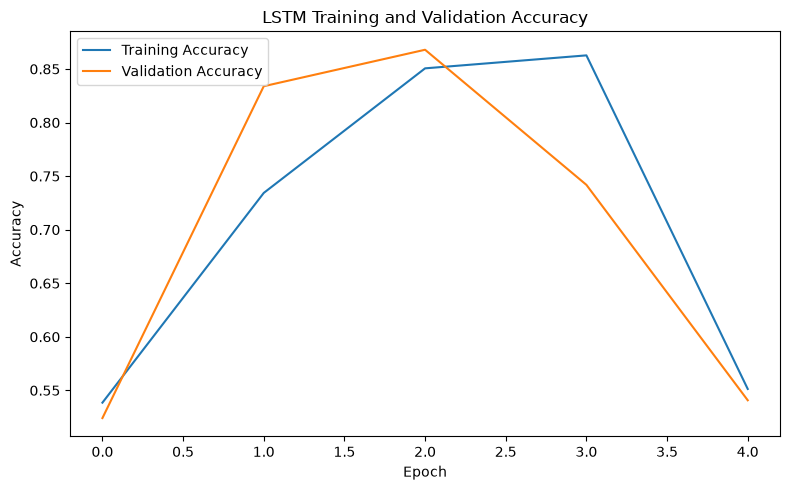

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "lstm_accuracy.png")
plt.show()

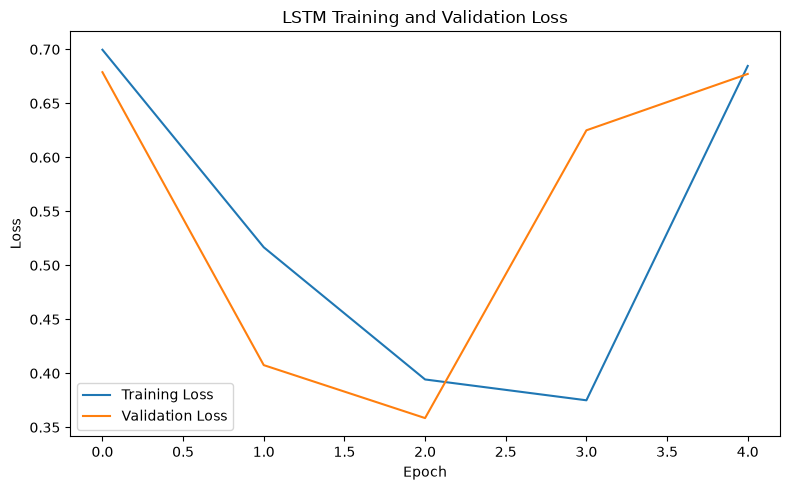

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "lstm_loss.png")
plt.show()

In [18]:
y_pred_prob = model.predict(X_test_pad).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("First 10 prediction probabilities:")
print(y_pred_prob[:10])

print("First 10 predicted labels:")
print(y_pred[:10])

245/245 ━━━━━━━━━━━━━━━━━━━━ 64s 250ms/step
First 10 prediction probabilities:
[0.6567806  0.01890843 0.6606275  0.7823267  0.01890841 0.65703595
 0.7823267  0.03820391 0.782411   0.7825792 ]
First 10 predicted labels:
[1 0 1 1 0 1 1 0 1 1]


In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("LSTM Evaluation Results")
print("-----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake News", "Real News"]))

LSTM Evaluation Results
-----------------------
Accuracy : 0.8730179028132993
Precision: 0.8203711014607186
Recall   : 0.9804199103562161
F1-score : 0.8932831810854379
ROC-AUC  : 0.9010221043555147

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.97      0.75      0.84      3581
   Real News       0.82      0.98      0.89      4239

    accuracy                           0.87      7820
   macro avg       0.90      0.86      0.87      7820
weighted avg       0.89      0.87      0.87      7820



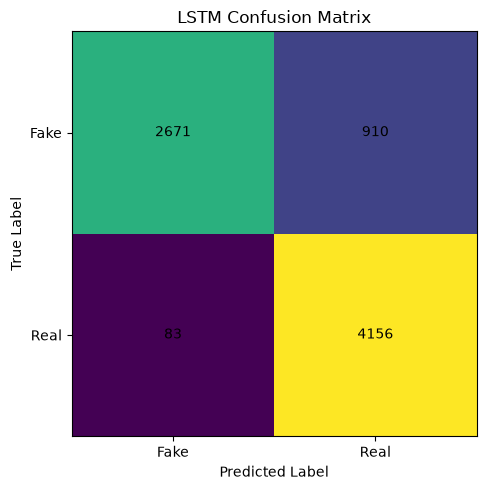

[[2671  910]
 [  83 4156]]


In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_confusion_matrix.png")
plt.show()

print(cm)

In [21]:
metrics = {
    "model": "LSTM",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "max_words": MAX_WORDS,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "batch_size": 64
}

metrics_df = pd.DataFrame([metrics])

metrics_path = METRICS_DIR / "lstm_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)

print("Metrics saved to:", metrics_path)

,model,accuracy,precision,recall,f1_score,roc_auc,max_words,max_len,embedding_dim,batch_size
0,LSTM,0.873018,0.820371,0.98042,0.893283,0.901022,20000,300,128,64


Metrics saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\reports\metrics\lstm_metrics.csv


In [22]:
model_path = MODELS_DIR / "lstm_model.keras"
tokenizer_path = MODELS_DIR / "lstm_tokenizer.json"

model.save(model_path)

tokenizer_json = tokenizer.to_json()
with open(tokenizer_path, "w", encoding="utf-8") as file:
    file.write(tokenizer_json)

print("LSTM model saved to:", model_path)
print("Tokenizer saved to:", tokenizer_path)

LSTM model saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\models\lstm_model.keras
Tokenizer saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\models\lstm_tokenizer.json


In [24]:
def predict_news_lstm(text):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded)[0][0]
    label = 1 if probability >= 0.5 else 0

    result = "Real News" if label == 1 else "Fake News"

    return result, probability


sample_news = """
Government officials announced new economic reforms after a press conference.
"""

result, probability = predict_news_lstm(sample_news)

print("Prediction:", result)
print("Probability:", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
Prediction: Real News
Probability: 0.78232676
